In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [2]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

In [3]:
df = pd.read_csv("TN womens crime datasets.txt")

In [4]:
print("Dataset Preview")
print(df.head())


Dataset Preview
   Year    District         Area  Crime_Type  Victim_Age     Time Urban_Rural  \
0  2021     Chennai      T Nagar        Rape          23    Night       Urban   
1  2021     Chennai    Velachery     Assault          31  Evening       Urban   
2  2021     Chennai     Tambaram  Kidnapping          17    Night       Urban   
3  2021  Coimbatore  Gandhipuram        Rape          26    Night       Urban   
4  2021  Coimbatore     RS Puram     Assault          35  Morning       Urban   

   Police_Station  Crime_Count  
0      T Nagar PS           18  
1    Velachery PS            9  
2     Tambaram PS           14  
3  Gandhipuram PS           20  
4     RS Puram PS            6  


In [5]:
print("\nMissing Values")
print(df.isnull().sum())



Missing Values
Year              0
District          0
Area              0
Crime_Type        0
Victim_Age        0
Time              0
Urban_Rural       0
Police_Station    0
Crime_Count       0
dtype: int64


In [6]:
def safety_level(crime_count):

    if crime_count <= 5:
        return "Low"

    elif crime_count <= 15:
        return "Medium"

    else:
        return "High Danger"

df["Safety_Level"] = df["Crime_Count"].apply(safety_level)

print("\nSafety Level Sample")
print(df[[
    "District",
    "Area",
    "Crime_Count",
    "Safety_Level"
]].head())



Safety Level Sample
     District         Area  Crime_Count Safety_Level
0     Chennai      T Nagar           18  High Danger
1     Chennai    Velachery            9       Medium
2     Chennai     Tambaram           14       Medium
3  Coimbatore  Gandhipuram           20  High Danger
4  Coimbatore     RS Puram            6       Medium


In [8]:
district_analysis = df.groupby(
    "District"
)["Crime_Count"].sum()

print("\nTop Dangerous Districts")
print(
    district_analysis.sort_values(
        ascending=False
    ).head(10)
)

top_districts = district_analysis.sort_values(
    ascending=False
).head(10)


Top Dangerous Districts
District
Chennai       298
Coimbatore    155
Madurai       145
Trichy        106
Cuddalore     103
Tiruppur      100
Dindigul       82
Erode          80
Namakkal       80
Nilgiris       70
Name: Crime_Count, dtype: int64


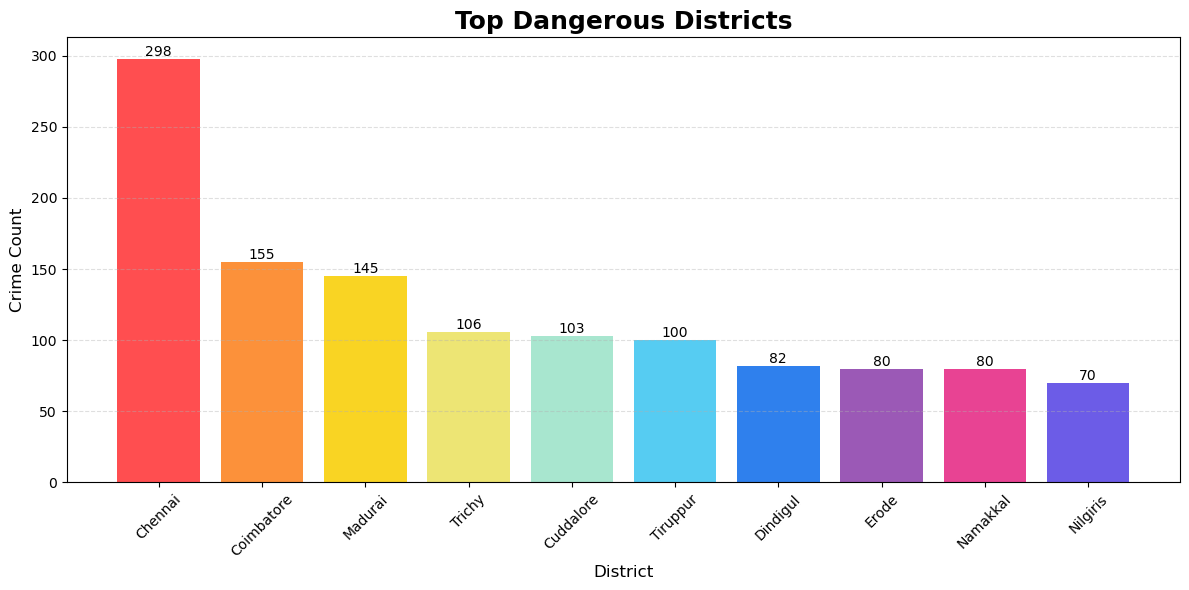

In [11]:
plt.figure(figsize=(12,6))

colors = [
    '#FF4E50',
    '#FC913A',
    '#F9D423',
    '#EDE574',
    '#A8E6CF',
    '#56CCF2',
    '#2F80ED',
    '#9B59B6',
    '#E84393',
    '#6C5CE7'
]
bars = plt.bar(
    top_districts.index,
    top_districts.values,
    color=colors
)

plt.title(
    "Top Dangerous Districts",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("District", fontsize=12)
plt.ylabel("Crime Count", fontsize=12)

plt.xticks(rotation=45)
for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height()+2,
        int(bar.get_height()),
        ha='center'
    )

plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()




Top Districts With Rape Cases
District
Coimbatore    120
Chennai       114
Trichy        106
Cuddalore     103
Tiruppur      100
Madurai        95
Dindigul       82
Erode          80
Nilgiris       70
Name: Crime_Count, dtype: int64


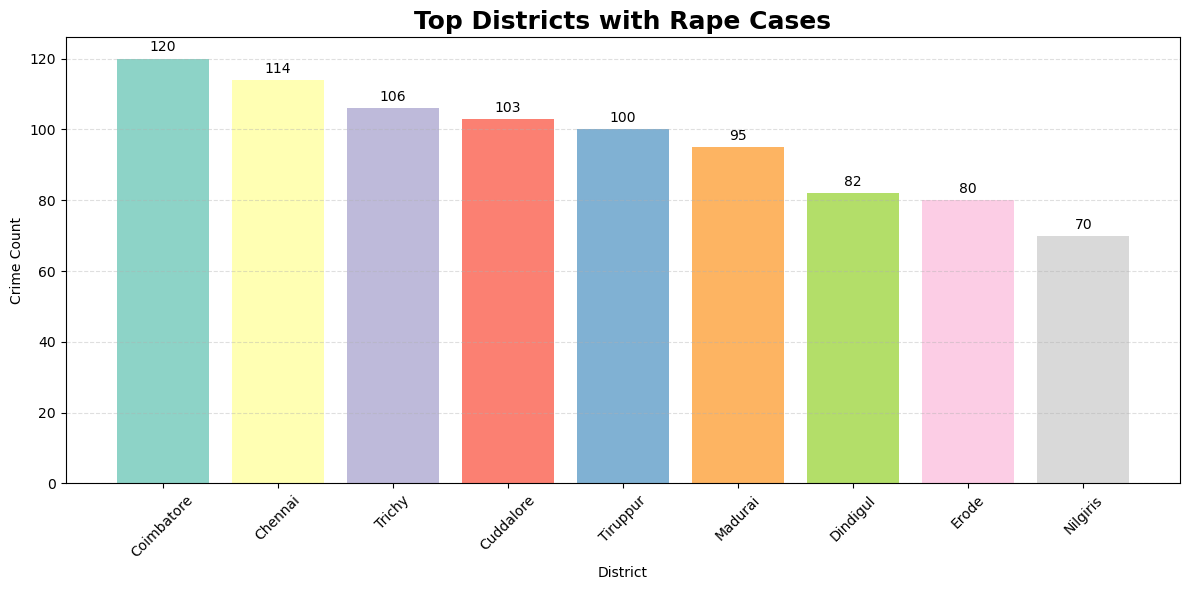

In [12]:
rape_data = df[
    df["Crime_Type"] == "Rape"
]

rape_by_district = rape_data.groupby(
    "District"
)["Crime_Count"].sum()

top_rape = rape_by_district.sort_values(
    ascending=False
).head(10)

print("\nTop Districts With Rape Cases")
print(top_rape)
plt.figure(figsize=(12,6))

bars = plt.bar(
    top_rape.index,
    top_rape.values,
    color=plt.cm.Set3(
        np.arange(len(top_rape))
    )
)

plt.title(
    "Top Districts with Rape Cases",
    fontsize=18,
    fontweight='bold'
)
plt.xlabel("District")
plt.ylabel("Crime Count")

plt.xticks(rotation=45)

for bar in bars:
    plt.text(
        bar.get_x()+bar.get_width()/2,
        bar.get_height()+2,
        int(bar.get_height()),
        ha='center'
    )

plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

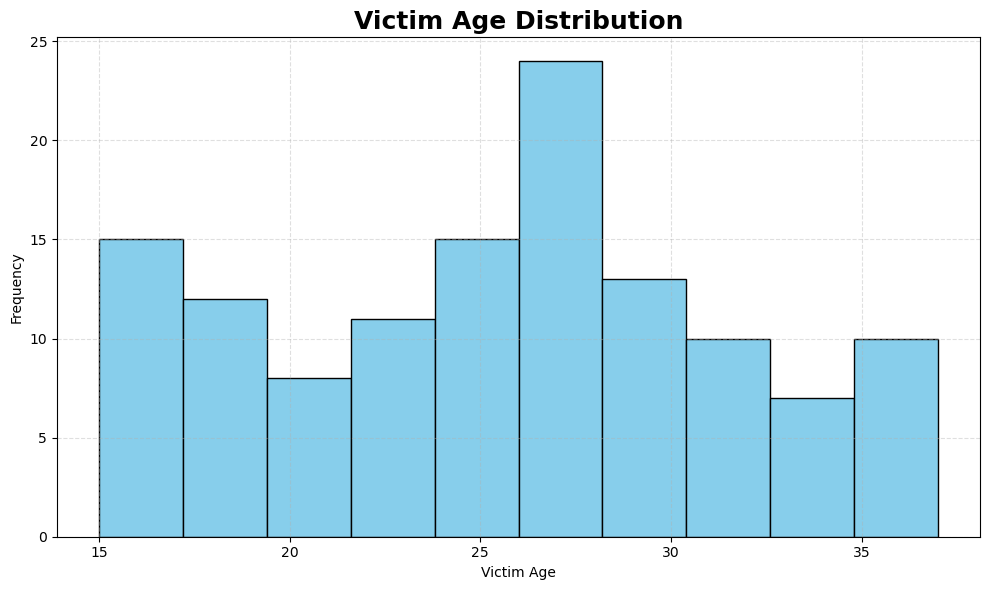

In [13]:
plt.figure(figsize=(10,6))

plt.hist(
    df["Victim_Age"],
    bins=10,
    color='skyblue',
    edgecolor='black'
)

plt.title(
    "Victim Age Distribution",
    fontsize=18,
    fontweight='bold'
)
plt.xlabel("Victim Age")
plt.ylabel("Frequency")

plt.grid(
    linestyle='--',
    alpha=0.4
)

plt.tight_layout()
plt.show()


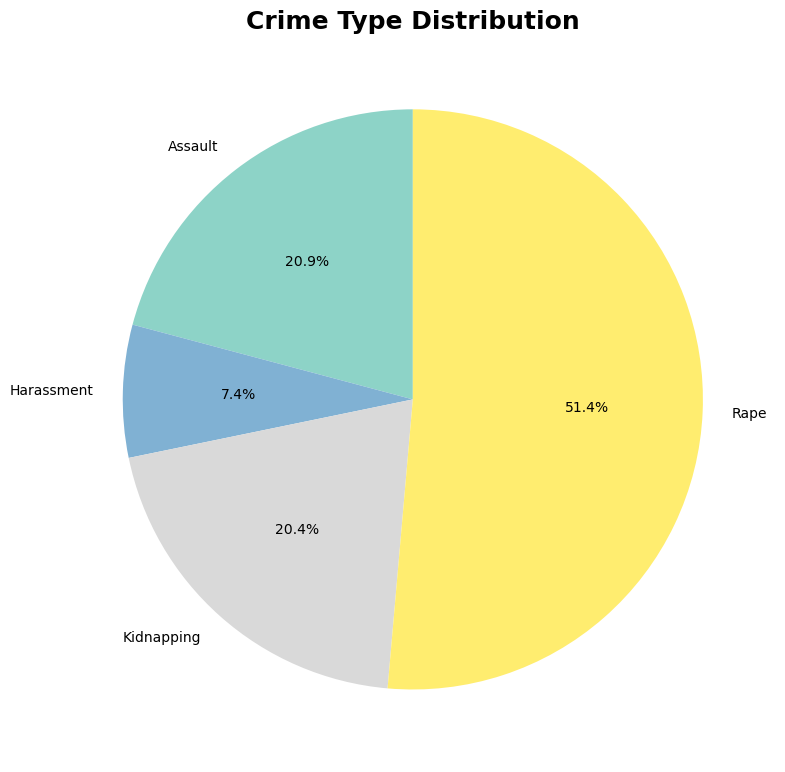

In [14]:
crime_type = df.groupby(
    "Crime_Type"
)["Crime_Count"].sum()

plt.figure(figsize=(8,8))

crime_type.plot(
    kind='pie',
    autopct='%1.1f%%',
    startangle=90,
    colormap='Set3'
)

plt.title(
    "Crime Type Distribution",
    fontsize=18,
    fontweight='bold'
    )

plt.ylabel("")

plt.tight_layout()
plt.show()


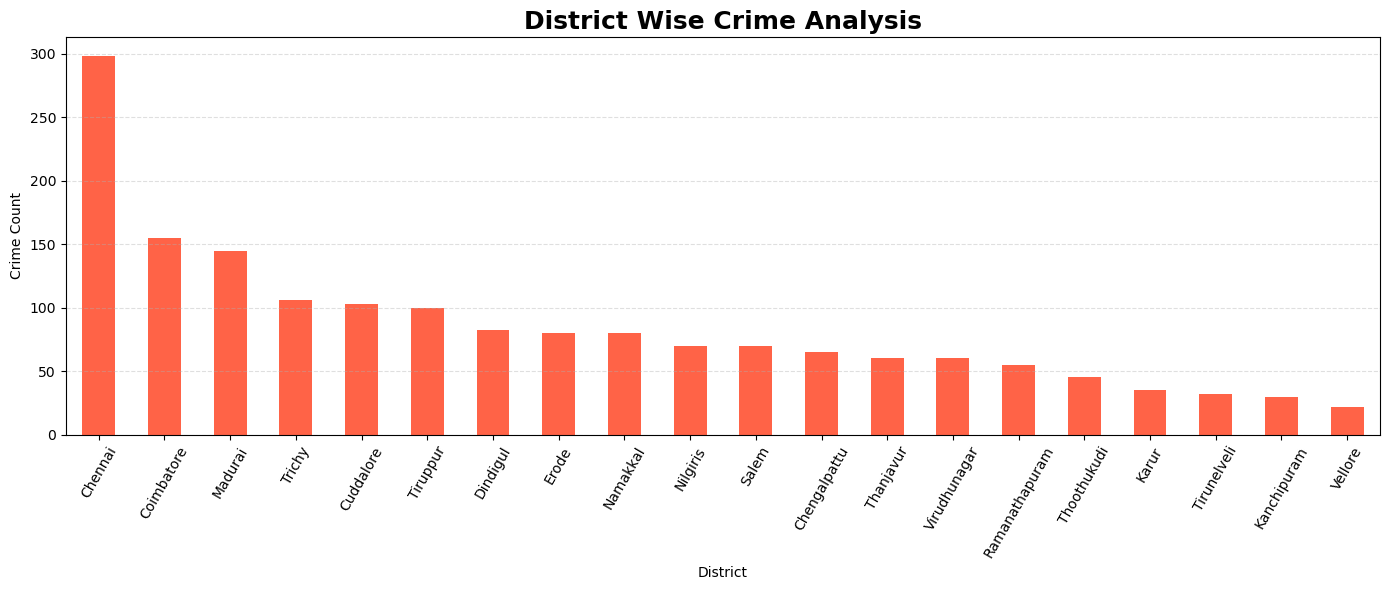

In [15]:
district_analysis.sort_values(
    ascending=False
).plot(
    kind='bar',
    figsize=(14,6),
    color='tomato'
)

plt.title(
    "District Wise Crime Analysis",
    fontsize=18,
    fontweight='bold'
)

plt.xlabel("District")
plt.ylabel("Crime Count")
plt.xticks(rotation=60)

plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()



In [16]:
le = LabelEncoder()

columns = [
    'District',
    'Area',
    'Crime_Type',
    'Time',
    'Urban_Rural',
    'Police_Station'
]

for col in columns:
    df[col] = le.fit_transform(df[col])
    X = df[[
    'Year',
    'District',
    'Area',
    'Crime_Type',
    'Victim_Age',
    'Time',
    'Urban_Rural',
    'Police_Station'
]]

y = df['Crime_Count']


In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)
model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(
    X_train,
    y_train
)
predictions = model.predict(
    X_test
)

print("\nPredicted Crime Counts")
print(predictions)



Predicted Crime Counts
[14.07  6.24  5.2  10.84 21.59 18.39  9.19  8.3  15.47  6.67 15.23 20.6
 19.93 13.17 18.8  16.53 14.57 10.95  5.45  8.95 12.2  23.53 20.56  8.69
  7.01]


In [18]:

score = model.score(
    X_test,
    y_test
)

print(
    "\nModel Accuracy Score : ",
    round(score*100,2),
    "%"
)


Model Accuracy Score :  91.93 %


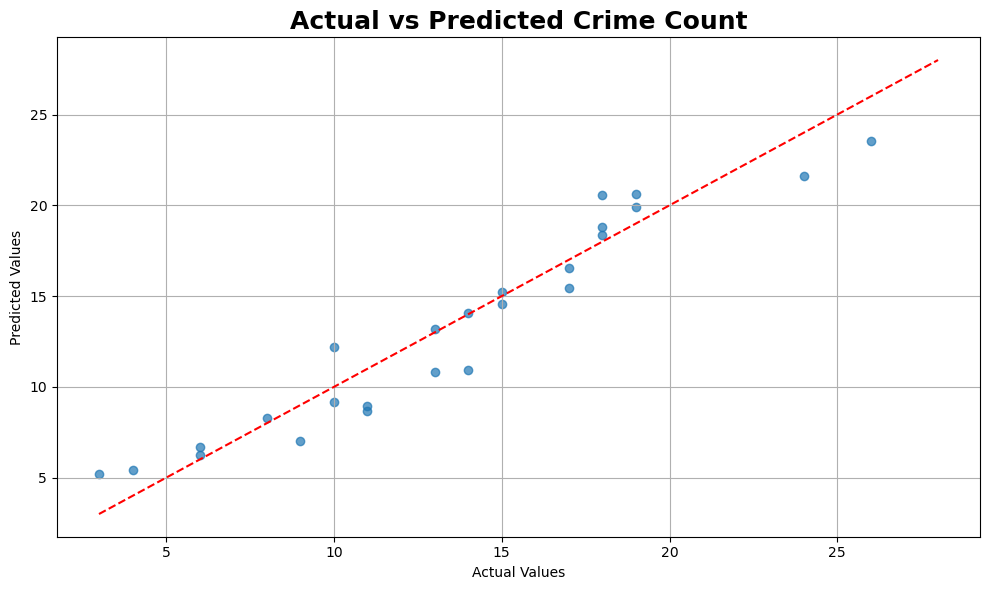

In [19]:
plt.figure(figsize=(10,6))

plt.scatter(
    y_test,
    predictions,
    alpha=0.7
)

plt.plot(
    [y.min(), y.max()],
    [y.min(), y.max()],
    'r--'
)
plt.title(
    "Actual vs Predicted Crime Count",
    fontsize=18,
    fontweight='bold'
)

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")

plt.grid(True)

plt.tight_layout()
plt.show()

In [20]:
sample_data = pd.DataFrame([[
    2027,
    3,
    12,
    2,
    24,
    2,
    1,
    15
]], columns=[
    'Year',
    'District',
    'Area',
    'Crime_Type',
    'Victim_Age',
    'Time',
    'Urban_Rural',
    'Police_Station'
])

future_prediction = model.predict(
    sample_data
    )

predicted_crime = future_prediction[0]

print(
    "\nPredicted Future Crime Count :",
    round(predicted_crime,2)
)


Predicted Future Crime Count : 20.14


In [21]:
if predicted_crime <= 5:
    safety = "Low"

elif predicted_crime <= 15:
    safety = "Medium"

else:
    safety = "High Danger"

print(
    "Predicted Safety Level :",
    safety
)


Predicted Safety Level : High Danger


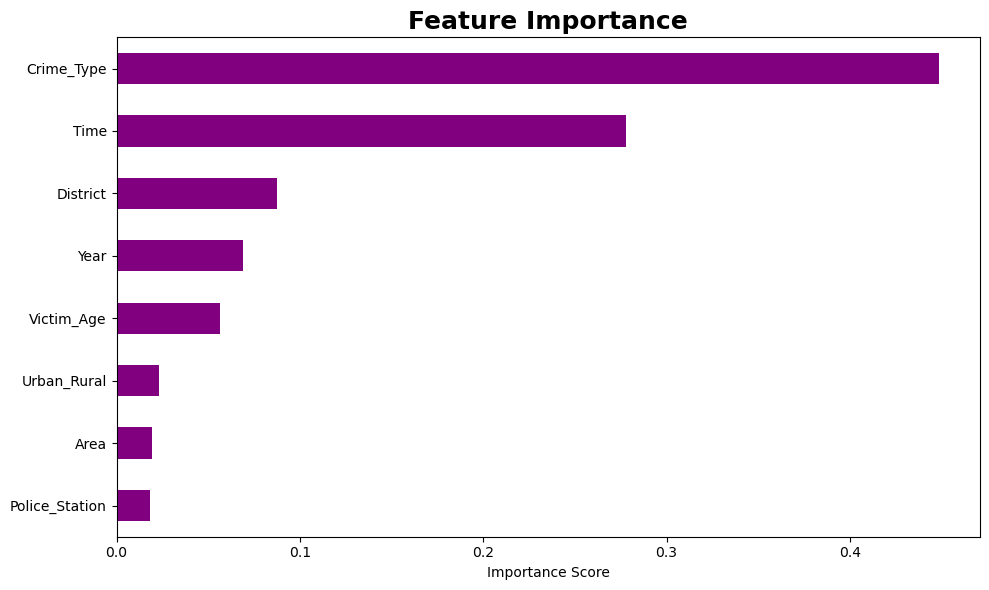

In [23]:
importance = pd.Series(
    model.feature_importances_,
    index=X.columns
)

importance.sort_values(
    ascending=True
).plot(
    kind='barh',
    figsize=(10,6),
    color='purple'
)

plt.title(
    "Feature Importance",
    fontsize=18,
    fontweight='bold'
)

plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()